<a href="https://colab.research.google.com/github/Pragzz05/Heart-Disease-Prediction-using-Multiple-Machine-Learning-Algorithms/blob/main/models/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Import Libraries**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Step 2: Load dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Ml_data_set/HeartDiseaseTrain-Test.csv')
print(df.head())

   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1 

**Step 3: Preprocessing**

In [ ]:
# Clean and prepare the dataset (handling missing values, etc.)

print(df.isnull().sum())


age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


**Step 4: Feature Selection and Encoding**

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

**Step 5: Data Splitting**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Step 6: Model Training using Random Forest**

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Step 7: Model Prediction on Test Data**

In [ ]:
y_pred = model.predict(X_test)

** Step 8: Model Evaluation**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



**Step 9: Confusion Matrix Visualization**

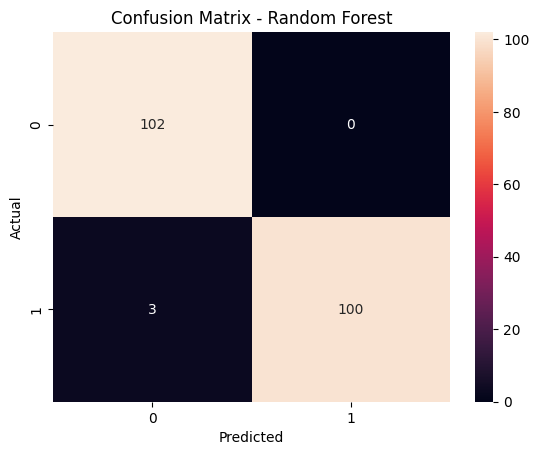

In [ ]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

**Step 10: Feature Importance**

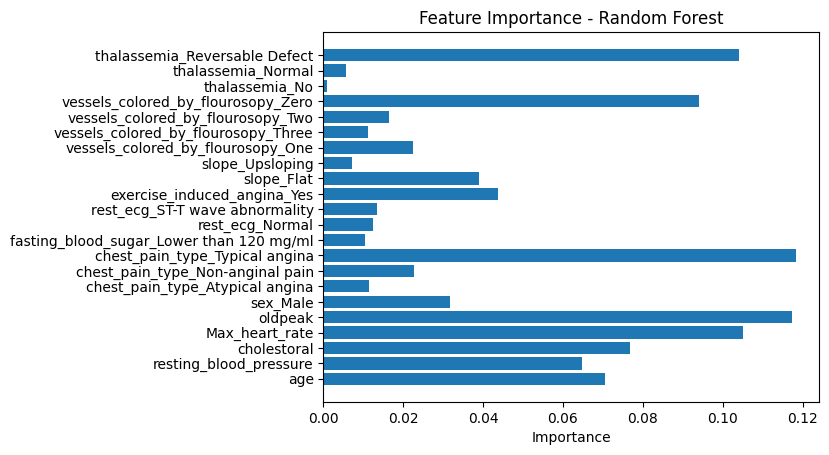

In [ ]:

importances = model.feature_importances_
feature_names = X.columns

plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()

**Step 11: Sample Prediction (New Patient)**

In [ ]:
sample_values = {
    'age': 52,
    'sex': 1,
    'chest_pain_type': 2,
    'resting_blood_pressure': 125,
    'cholestoral': 212,
    'fasting_blood_sugar': 0,
    'rest_ecg': 1,
    'Max_heart_rate': 168,
    'exercise_induced_angina': 0,
    'oldpeak': 1.0,
    'slope': 2,
    'vessels_colored_by_flourosopy': 2,
    'thalassemia': 3
}

sample_df = pd.DataFrame([sample_values])

# Encode + align
sample_df = pd.get_dummies(sample_df, drop_first=True)
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = model.predict(sample_df)

if prediction[0] == 1:
    print("The person is likely to have Heart Disease")
else:
    print("The person is NOT likely to have Heart Disease")

The person is likely to have Heart Disease
